### Objectives  
* Develop a classification model using Decision Tree Algorithm.  
* Apply Decision Tree classification on a real world dataset.

### About dataset

Imagine that you are a medical researcher compiling data for a study. You have collected data about a set of patients, all of  
whom suffered from the same illness. During their course of treatment, each patient responded to one of 5 medications, Drug A,  
Drug B, Drug C, Drug X and Drug Y.  

Part of your job is to build a model to find out which drug might be appropriate for a future patient with the same illness. The features of this dataset are the Age, Sex, Blood Pressure, and Cholesterol of the patients, and the target is the drug that each patient responded to.

It is a sample of a multiclass classifier, and you can use the training part of the dataset to build a decision tree, and then use it to predict the class of an unknown patient or to prescribe a drug to a new patient.

In [65]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

__Load data__

In [66]:
dataFrame = pd.read_csv('drug200.csv')

In [67]:
df = dataFrame.copy()
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


####  Data Analysis and pre-processing

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [69]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


This tells us that `4` out of the `6` features of this dataset are `categorical`, which will have to be converted into `numerical` ones to be used for modeling. For this, we can make use of __LabelEncoder__ from the Scikit-Learn library.

In [70]:
le_sex = LabelEncoder()
le_bp = LabelEncoder()
le_chol = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex']) 
df['BP'] = le_bp.fit_transform(df['BP'])
df['Cholesterol'] = le_chol.fit_transform(df['Cholesterol']) 
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,drugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,drugY
...,...,...,...,...,...,...
195,56,0,1,0,11.567,drugC
196,16,1,1,0,12.006,drugC
197,52,1,2,0,9.894,drugX
198,23,1,2,1,14.020,drugX


With this, now we have 5 parameters that can be used for modeling and 1 feature as the target variable. 
We can see from comparison of the data before Label encoding and after it, to note the following mapping.
<br>
For parameter 'Sex' : $M \rightarrow 1, F \rightarrow 0$ <br>
For parameter 'BP' : $High \rightarrow 0, Low \rightarrow 1, Normal \rightarrow 2$<br>
For parameter 'Cholesterol' : $High \rightarrow 0, Normal \rightarrow 1$

__Check for null value__

In [71]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

No missing values in any of the fields.

__To evaluate the correlation of the target variable with the input features, it will be convenient to map the different drugs to a numerical value.__   

* Also add one column for this 'Drug_num'

In [72]:
custom_map = {'drugA':0,'drugB':1,'drugC':2,'drugX':3,'drugY':4}
df['Drug_num'] = df['Drug'].map(custom_map)
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Drug_num
0,23,0,0,0,25.355,drugY,4
1,47,1,1,0,13.093,drugC,2
2,47,1,1,0,10.114,drugC,2
3,28,0,2,0,7.798,drugX,3
4,61,0,1,0,18.043,drugY,4
...,...,...,...,...,...,...,...
195,56,0,1,0,11.567,drugC,2
196,16,1,1,0,12.006,drugC,2
197,52,1,2,0,9.894,drugX,3
198,23,1,2,1,14.020,drugX,3


**Now we use the corr() function to find the correlation of the input variables with the target variable.**

In [73]:
df.drop('Drug', axis=1).corr()['Drug_num']

Age           -0.004828
Sex           -0.098573
BP             0.372868
Cholesterol    0.055629
Na_to_K        0.589120
Drug_num       1.000000
Name: Drug_num, dtype: float64

We can also understand the distribution of the dataset by plotting the count of the records with each drug recommendation.

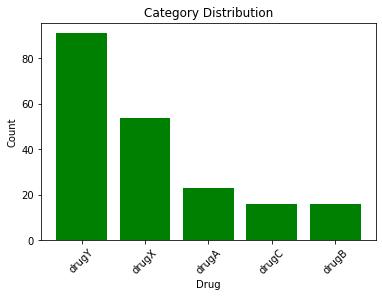

In [74]:
category_counts = df['Drug'].value_counts()

# Plot the count plot
plt.bar(category_counts.index, category_counts.values, color='green')
plt.xlabel('Drug')
plt.ylabel('Count')
plt.title('Category Distribution')
plt.xticks(rotation=45)  # Rotate labels for better readability if needed
plt.show()

This shows us the distribution of the different classes, clearly indicating that Drug X and Drug Y have many more records in comparison to the other 3.

__Modeling__

For modeling this dataset with a Decision tree classifier, we first split the dataset into training and testing subsets. For this, we separate the target variable from the input variables.

In [75]:
y = df['Drug']
X = df.drop(['Drug','Drug_num'], axis=1)

Now, use the __train_test_split()__ function to separate the training data from the testing data. We can make use of 30% of the data for testing and the rest for training the Decision tree.

In [76]:
X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.3, random_state=32, stratify=y)

We can now define the Decision tree classifier as drugTree and train it with the training data.

__checking max depth__

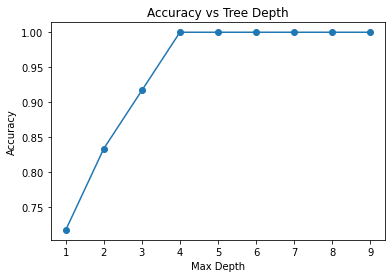

In [77]:
depths = range(1, 10)
accuracies = []
for d in depths:
    clf = DecisionTreeClassifier(criterion="entropy", max_depth=d)
    clf.fit(X_trainset, y_trainset)
    accuracies.append(metrics.accuracy_score(y_testset, clf.predict(X_testset)))

plt.plot(depths, accuracies, marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Tree Depth')
plt.show()

From the plot, accuracy stabilizes at depth 4, so we proceed with max_depth=4.

__Taking max_depth = 4__

In [78]:
drugTree = DecisionTreeClassifier(criterion="entropy", max_depth = 4)

In [79]:
drugTree.fit(X_trainset,y_trainset)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

**Evaluation**

Now that we have trained the decision tree, we can use it to generate the predictions on the test set.

In [80]:
tree_predictions = drugTree.predict(X_testset)

We can now check the accuracy of our model by using the accuracy metric.

In [81]:
print("Decision Trees's Accuracy: ", metrics.accuracy_score(y_testset, tree_predictions))

Decision Trees's Accuracy:  1.0


This means that the model was able to correctly identify the labels of 98.33%, i.e. 59 out of 60 test samples.

**Visualize the tree**  
To understand the classification criteria derived by the Decision Tree, we may generate the tree plot.

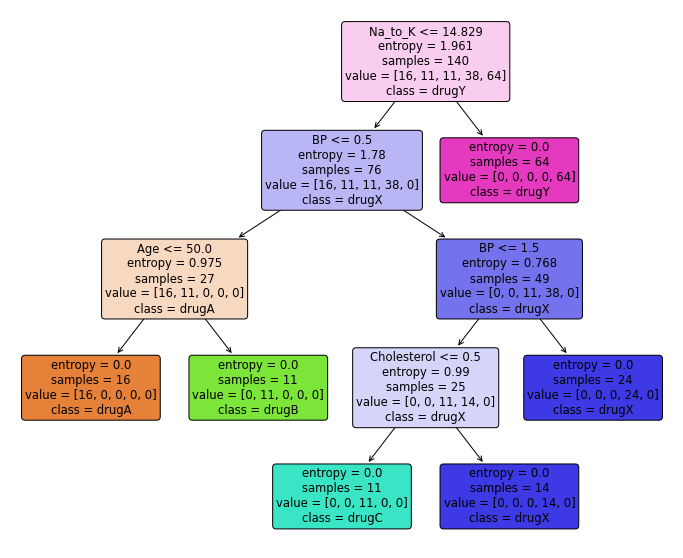

In [96]:
#plot_tree(drugTree)
#plt.show()

plt.figure(figsize=(12, 10))
plot_tree(drugTree, feature_names=X.columns,
          class_names=drugTree.classes_,
          filled=True, rounded=True)
plt.show()

From this tree, we can derive the criteria developed by the model to identify the class of each training sample. We can interpret them by tracing the criteria defined by tracing down from the root to the tree's leaf nodes.   

For instance, the decision criterion for Drug Y is ${Na\_to\_K} \gt 14.627$.

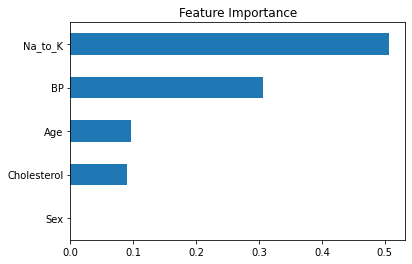

In [83]:
feat_importance = pd.Series(drugTree.feature_importances_, index=X.columns)
feat_importance.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()

**confusion matrix**

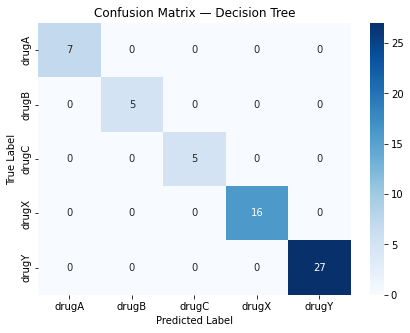

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        16
       drugY       1.00      1.00      1.00        27

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [84]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

labels = sorted(df['Drug'].unique())
cm = confusion_matrix(y_testset, tree_predictions, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Decision Tree')
plt.show()

print(classification_report(y_testset, tree_predictions))

__gini vs entropy__

In [85]:
for criterion in ['gini', 'entropy']:
    clf = DecisionTreeClassifier(criterion=criterion, max_depth=4)
    clf.fit(X_trainset, y_trainset)
    acc = metrics.accuracy_score(y_testset, clf.predict(X_testset))
    print(f"{criterion}: {acc:.4f}")

gini: 1.0000
entropy: 1.0000


In [88]:
for criterion in ['gini', 'entropy']:
    clf = DecisionTreeClassifier(criterion=criterion, max_depth=4)
    scores = cross_val_score(clf, X, y, cv=5)
    print(f"{criterion}: {scores.mean():.4f} ± {scores.std():.4f}")

gini: 0.9850 ± 0.0300
entropy: 0.9850 ± 0.0300


Cross-validation instead of single split

In [86]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(drugTree, X, y, cv=5)
print(f"CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

CV Accuracy: 0.9850 ± 0.0300


__Predict for a new patient__

In [87]:
# Age=45, Sex=Male(1), BP=High(0), Cholesterol=High(0), Na_to_K=20.0

new_patient = pd.DataFrame([[45, 1, 0, 0, 20.0]], 
                            columns=X.columns)
print("Predicted Drug:", drugTree.predict(new_patient)[0])

Predicted Drug: drugY
